# Fixed points of feedback diagrams

A diagram with a feedback loop has stream semantics — `to_stream` and
`unroll` give it at each finite time — and approximate fixed-point semantics
through `fix`, which estimates the state the loop settles into. Both are built
from the same open one-step channel.

## Part 1: one beam splitter, one photon per step

The smallest instance worth studying. A photon enters the first input at every
step; the second output is fed back into the second input.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from discopy.symmetric import Equation
from optyx import photonic
from optyx.channel import Channel, Diagram, Discard, qmode
from optyx.core import diagram
from optyx.core.backends import DiscopyBackend

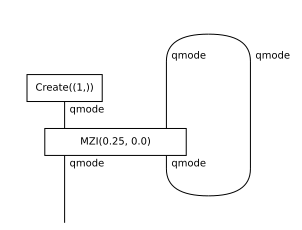

In [2]:
def learner(theta, phi=0.0):
    return (photonic.Create(1) @ qmode >> photonic.MZI(theta, phi)).feedback(
        mem=qmode, initial_state=photonic.Create(0))

learner(0.25).draw(figsize=(4, 3))

Photon number is conserved and the drive has a definite number, so the loop
and output occupations are perfectly correlated: tracing out one destroys
every coherence between different photon numbers. The fixed point is
**diagonal in the Fock basis**, and the external phase `phi`, being diagonal
in number, cannot affect it.

In [3]:
rho = learner(.06, .125).fix(method="eigen", cutoff=8).density_matrix
off_diagonal = np.abs(rho - np.diag(np.diag(rho))).max()
print(f"largest off-diagonal element: {off_diagonal:.2e}")

base = learner(.06, 0).fix(method="eigen", cutoff=8).density_matrix
for phi in (0, .125, .25, .5, .75):
    other = learner(.06, phi).fix(method="eigen", cutoff=8).density_matrix
    print(f"phi={phi:5.3f}  max difference from phi=0: "
          f"{np.abs(other - base).max():.2e}")

largest off-diagonal element: 0.00e+00


phi=0.000  max difference from phi=0: 0.00e+00


phi=0.125  max difference from phi=0: 2.22e-16


phi=0.250  max difference from phi=0: 2.22e-16


phi=0.500  max difference from phi=0: 1.11e-16


phi=0.750  max difference from phi=0: 2.22e-16


### The mean is exactly one

With $b_{\mathrm{out}}=-r^*a_{\mathrm{in}}+t^*b_{\mathrm{in}}$, a Fock input
and a number-diagonal memory kill the cross terms, so $\bar n'=R+T\bar n$ and
the fixed point forces $\langle n\rangle=1$: one photon in per step, one out.
Writing $T$ for the probability that the fresh photon leaves immediately, the
variance is $4T/(1+T)$ — exactly twice the $2T/(1+T)$ of distinguishable
particles undergoing the same binomial thinning. Bunching doubles the variance
and leaves the mean alone.

In [4]:
def statistics(distribution):
    n = np.arange(len(distribution))
    mean = (n * distribution).sum()
    return mean, (n * n * distribution).sum() - mean ** 2


records = []
for theta, cutoff in ((.02, 6), (.04, 7), (.06, 8), (.08, 9)):
    rho = learner(theta).fix(method="eigen", cutoff=cutoff).density_matrix
    p = np.real(np.diag(rho))
    p = p / p.sum()
    mean, variance = statistics(p)
    records.append((theta, np.sin(np.pi * theta) ** 2, mean, variance - mean, p))
    print(f"theta={theta:.2f}  T={np.sin(np.pi*theta)**2:.4f}  "
          f"mean={mean:.6f}  Q={variance-mean:+.6f}")

theta=0.02  T=0.0039  mean=1.000000  Q=-0.968707


theta=0.04  T=0.0157  mean=1.000000  Q=-0.878220


theta=0.06  T=0.0351  mean=1.000000  Q=-0.738162


theta=0.08  T=0.0618  mean=1.000000  Q=-0.562862


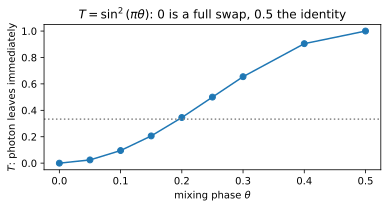

In [5]:
thetas = np.array([0, .05, .1, .15, .2, .25, .3, .4, .5])
transmission = []
for theta in thetas:
    amps = (photonic.Create(1, 0) >> photonic.MZI(theta, 0)
            ).eval(DiscopyBackend()).amplitudes()
    transmission.append(abs(amps.get((1, 0), 0)) ** 2)
transmission = np.array(transmission)

figure, axis = plt.subplots(figsize=(5.5, 3))
axis.plot(thetas, transmission, "o-")
axis.axhline(1 / 3, ls=":", color="grey")
axis.set_xlabel(r"mixing phase $\theta$")
axis.set_ylabel(r"$T$: photon leaves immediately")
axis.set_title(r"$T=\sin^2(\pi\theta)$: 0 is a full swap, 0.5 the identity")
figure.tight_layout()
plt.show()

$\theta=0$ is a full swap: the loop holds exactly one photon forever.
$\theta=0.5$ is the identity: the photon leaves and the loop never fills.

### The stationary distribution and its tail

Only the full swap gives a single Fock state. For every $T>0$ the fixed point
has weight on every photon number; what changes is how fast the tail decays.

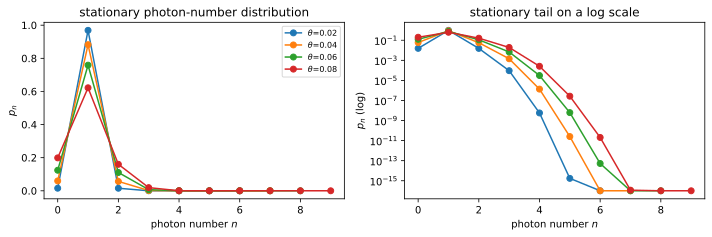

In [6]:
figure, axes = plt.subplots(1, 2, figsize=(10, 3.4))
for theta, T, mean, Q, p in records:
    occupations = np.arange(len(p))
    axes[0].plot(occupations, p, "o-", label=fr"$\theta$={theta:.2f}")
    axes[1].semilogy(occupations, np.maximum(p, 1e-16), "o-")
axes[0].set_xlabel("photon number $n$")
axes[0].set_ylabel("$p_n$")
axes[0].set_title("stationary photon-number distribution")
axes[0].legend(fontsize=8)
axes[1].set_xlabel("photon number $n$")
axes[1].set_ylabel("$p_n$ (log)")
axes[1].set_title("stationary tail on a log scale")
figure.tight_layout()
plt.show()

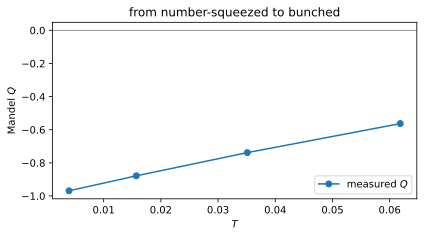

In [7]:
figure, axis = plt.subplots(figsize=(6, 3.4))
axis.plot([r[1] for r in records], [r[3] for r in records], "o-",
          label="measured $Q$")
axis.axhline(0, color="grey", lw=.8)
axis.set_xlabel("$T$")
axis.set_ylabel("Mandel $Q$")
axis.set_title("from number-squeezed to bunched")
axis.legend()
figure.tight_layout()
plt.show()

### What this state is not

The fixed point is a classical mixture of Fock states with mean exactly one,
and it belongs to none of the usual families. Not **coherent**: it is
Fock-diagonal, while a coherent state is pure with large coherences. Not
**Poissonian**: $Q=\mathrm{Var}(N)-\langle N\rangle$ runs from $-1$ at the
full swap to $+1$ as the loop decouples, and where it crosses zero only the
second moment matches, not the distribution. Not **thermal**, which would need
$Q=+1$ throughout. And not **Gaussian**, because the only Fock-diagonal
single-mode Gaussian states are the thermal ones — so being Gaussian would
mean being thermal. Its factorial moments are $F_r=r!\,F_r^{\mathrm C}$
against the distinguishable chain, reaching the thermal $r!$ only as
$T\to1$.

## Part 2: complexity of stationary boson sampling

Now the general problem. Let $U$ be an arbitrary number-preserving unitary on
$M+L$ modes. At every time step the $M$ external inputs carry a fixed product
state $\psi$, the $L$ remaining inputs carry the loop, $M$ outputs are
detected and $L$ outputs are fed back. **Stationary boson sampling** asks for
the output distribution once this has settled.

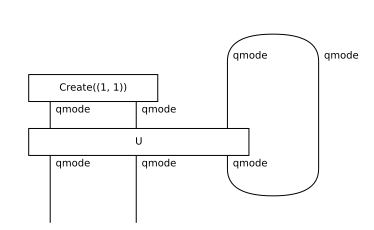

In [8]:
def random_unitary(size, seed=7):
    rng = np.random.default_rng(seed)
    matrix = rng.normal(size=(size, size)) + 1j * rng.normal(size=(size, size))
    unitary, upper = np.linalg.qr(matrix)
    return unitary * (np.diag(upper) / np.abs(np.diag(upper)))


U = photonic.Gate(random_unitary(3), 3, 3, "U")

def feedback_sampler(occupation):
    psi = photonic.Create(*occupation)
    return (psi @ qmode >> U).feedback(
        mem=qmode, initial_state=photonic.Create(0))

process = feedback_sampler((1, 1))
process.draw(figsize=(5, 3))

One step contains the two maps. Tracing out the detected modes updates the
loop, $\rho\mapsto\mathrm{Tr}_M[U(|\psi\rangle\langle\psi|\otimes\rho)
U^\dagger]$; tracing out the next loop instead gives the visible output.
`power` iterates the first and reads out once; `eigen` builds the transfer
operator of the first, solves for its stationary $\rho_\star$, and reads out
once.

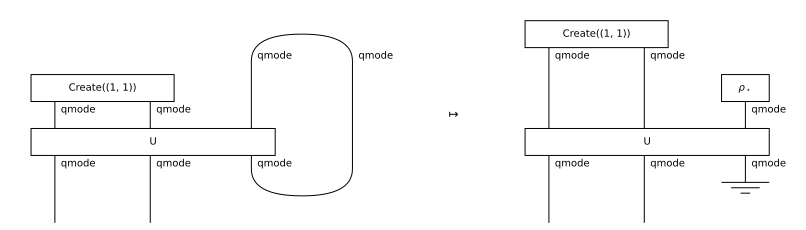

In [9]:
stationary = Channel(
    r"$\rho_\star$",
    diagram.Box(r"$\rho_\star$", diagram.Ty(), diagram.Mode(2)),
    cod=qmode, env=diagram.Mode(1))
readout = (photonic.Create(1, 1) @ stationary >> U
           >> Diagram.id(qmode ** 2) @ Discard(qmode))
Equation(process, readout, symbol=r"$\mapsto$").draw(figsize=(11, 3))

### Time and space

Take $\psi=|1\rangle^{\otimes M}$ and run $n$ steps. At most $M$ photons enter
per step, so after $n$ steps the loop holds at most $nM$ photons and its
truncated dimension is

$$h(L,n,M)=\binom{nM+L}{L}\sim\frac{(nM)^{L}}{L!}.$$

Write $\mathrm{cost}(U)$ and $\mathrm{space}(U)$ for one application of the
doubled one-step channel. **As algorithms**:

| | time | space |
| --- | --- | --- |
| `power` | $O(n\,\mathrm{cost}(U))$ | $O(h^2+\mathrm{space}(U))$ |
| `eigen` | $O(h^2\,\mathrm{cost}(U)+h^6)$ | $O(h^4+\mathrm{space}(U))$ |

Space is the sharper separator. Power holds one density matrix on the loop,
$h^2$ numbers, and overwrites it each step. Eigen materialises the whole
transfer operator, an $h^2\times h^2$ matrix, so $h^4$ numbers — the square of
what power needs. That is what actually stops eigen first: the $h^4$ array
exhausts memory long before the $h^6$ solve exhausts patience, which is why
the truncation check refuses at cutoffs the timing study can still reach.

Two corrections to the time column, both forced by measurement:

* the $h^6$ eigensolve **never dominates at reachable sizes**, so eigen is
  *build-dominated* and scales like $h^2$, not $h^6$;
* power is **not linear in $n$ as implemented**: `fix` unrolls the history
  into one network and contracts it, rather than applying the channel to a
  density matrix once per step.

In [10]:
import time

cutoffs, eigen_times = [], []
for cutoff in (6, 7, 8, 9, 10):
    try:
        start = time.perf_counter()
        learner(.02).fix(method="eigen", cutoff=cutoff)
        eigen_times.append(time.perf_counter() - start)
        cutoffs.append(cutoff + 1)
    except ValueError:
        pass
eigen_slope = np.polyfit(np.log(cutoffs), np.log(eigen_times), 1)[0]

depths, power_times, widths, swaps = (2, 4, 6, 8), [], [], []
for depth in depths:
    start = time.perf_counter()
    learner(.02).fix(n_steps=depth, chi=8, backend=DiscopyBackend())
    power_times.append(time.perf_counter() - start)
    network = learner(.02).at_time(depth).double().to_tensor()
    widths.append(len(network.boxes))
    swaps.append(sum(1 for b in network.boxes if type(b).__name__ == "Swap"))
power_slope = np.polyfit(np.log(np.array(depths, float)),
                         np.log(power_times), 1)[0]
size_slope = np.polyfit(np.log(np.array(depths, float)),
                        np.log(widths), 1)[0]
swap_slope = np.polyfit(np.log(np.array(depths, float)),
                        np.log(swaps), 1)[0]

print(f"eigen : exponent in h  = {eigen_slope:.2f}"
      "   (h^2 build predicted 2, h^6 solve predicted 6)")
print(f"power : exponent in n  = {power_slope:.2f}"
      "   (one application per step predicts 1)")
print(f"        boxes {widths}, exponent {size_slope:.2f}")
print(f"        swaps {swaps}, exponent {swap_slope:.2f}")

eigen : exponent in h  = 1.90   (h^2 build predicted 2, h^6 solve predicted 6)
power : exponent in n  = 1.81   (one application per step predicts 1)
        boxes [68, 136, 212, 296], exponent 1.06
        swaps [8, 22, 44, 74], exponent 1.60


The eigen exponent lands near $2$, not $6$: the dense solve never gets to
dominate, so the build is the whole story and the $h^6$ term is asymptotic
decoration at any size this implementation can reach.

The power exponent sits well above $1$, and the box counts say where it does
*not* come from: the network grows essentially linearly in the depth, so this
is not a case of building a bigger diagram than necessary. Two things are
superlinear instead. The swap count grows faster than the depth — every step
adds an output wire that later steps must route past — and, contracted
exactly, the intermediate tensors grow as the contraction sweeps through the
history, so the cost per box rises with depth. Bounding the bond dimension
addresses the second; the first is pure routing, which a combinatorial-map
contraction removes by turning wire routing into index naming rather than
tensors.

Up to constants, simulation time follows the corrected costs — $h^2$ for
eigen, superlinear in $n$ for power — and not the idealised ones.

### Definitions

Everything below is stated in terms of five objects, so they are worth fixing
precisely.

**The unitary and its blocks.** $U$ is an $(M+L)\times(M+L)$ unitary acting on
mode operators, $a_i\mapsto\sum_j U_{ij}a_j$; it is passive, so it preserves
total photon number. Order the modes external-first, so

$$U=\begin{pmatrix}A & B\\ C & D\end{pmatrix},$$

with $A$ the $M\times M$ external-to-external block and $D$ the $L\times L$
**loop block**: $D_{ij}$ is the amplitude for a photon in loop mode $j$ to
stay in the loop, arriving in mode $i$. Its singular values are
$s_1\ge\cdots\ge s_L$, and $s_1=\|D\|$. Since $D$ is a sub-block of a unitary,
$s_1\le1$.

**The step channel.** With $\psi=|1\rangle^{\otimes M}$ injected on the
external inputs each step,

$$\Phi:\;\rho\;\longmapsto\;\operatorname{Tr}_M\!\big[
U(\psi\otimes\rho)U^\dagger\big]$$

is a CPTP map on states of the $L$ loop modes. $\rho_\star$ denotes a fixed
point, $\Phi(\rho_\star)=\rho_\star$.

**The loop chain and $h$.** Truncating each loop mode at $c$ photons gives the
loop a Hilbert space of dimension $h=c^L$ (or $h=\binom{nM+L}{L}$ under a
total-photon truncation, the form used in the cost table). Because $\Phi$
preserves Fock-diagonality, it restricts to a classical Markov chain on the
$h$ loop occupations, with transition matrix

$$P_{\mathbf m\mathbf n}
=\Pr[\text{loop}=\mathbf n\text{ after one step}\mid\text{loop}=\mathbf m],$$

obtained by applying $U$ to $|\psi,\mathbf m\rangle$ and summing $|\text{
amplitude}|^2$ over all external outcomes.

**$\lambda_2$.** $P$ is stochastic, so its eigenvalues satisfy
$1=|\lambda_1|\ge|\lambda_2|\ge\cdots$. We write $|\lambda_2|$ for the
second-largest eigenvalue *modulus* of $P$ — the **spectral gap** is
$1-|\lambda_2|$. It sets the asymptotic rate: $\|P^n(\mathbf m,\cdot)-\pi\|
\sim|\lambda_2|^n$ as $n\to\infty$, with $\pi$ the stationary distribution.
Taking $P$ rather than the full superoperator is the right choice here, and is
justified above: a Fock-diagonal start never leaves the population sector.

**$\eta$ and $n^\star$.** $\eta$ is the Dobrushin coefficient of $P$ defined
below, a bound valid at *every* $n$ rather than asymptotically. Given a target
total-variation error $\varepsilon$, the certified depth is
$n^\star(\varepsilon)=\lceil\log\varepsilon/\log\eta\rceil$, and the
asymptotic estimate replaces $\eta$ by $|\lambda_2|$.

In Part 1, $L=M=1$ and $D$ is the single number with $|D|^2=T$, which is why
$|\lambda_2|=T$ there.

### How long until it converges

Cost per step is half the question; the other half is how many steps. Write

$$\Phi_{U,\psi,L,M}:\;\rho\;\longmapsto\;
\operatorname{Tr}_M\!\big[U(\psi\otimes\rho)U^\dagger\big]$$

for one step of the general problem, a CPTP map on the $L$ loop modes. This is
a *quantum Markov chain* in the collision-model sense — a system meeting a
fresh ancilla $\psi$ at each step and the ancilla being discarded — so the
convergence theory for those applies (Ciccarello et al. 2022).

Three standard facts set what we can hope for. Every CPTP map is a contraction
in trace norm, so the distance to a fixed point never grows (Pérez-García et
al. 2006). If the fixed point $\rho_\star$ is unique, the asymptotic rate is
the second-largest eigenvalue modulus $|\lambda_2|$ of $\Phi$. But
$|\lambda_2|^n$ is **not** an upper bound at finite $n$: $\Phi$ is not normal,
and spectral estimates for non-normal Markov maps need the Jordan structure,
not just the spectrum (Szehr, Reeb and Wolf 2015). So $|\lambda_2|$ predicts
the depth an unrolling *eventually* needs, while a certified depth needs the
norm quantity of the next section.

The one-mode loop of Part 1 is the special case $L=M=1$ with a beam splitter,
and there the spectrum is elementary: $|\lambda_2|=T$, the survival
probability.

In [11]:
from scipy.linalg import expm

def loop_chain(T, cutoff=20):
    ladder = np.diag(np.sqrt(np.arange(1, cutoff + 1)), 1)
    identity = np.eye(cutoff + 1)
    a, b = np.kron(ladder, identity), np.kron(identity, ladder)
    unitary = expm(np.arcsin(np.sqrt(1 - T)) * (a.conj().T @ b - a @ b.conj().T))
    chain = np.zeros((cutoff + 1, cutoff + 1))
    for n in range(cutoff):
        vector = np.zeros((cutoff + 1) ** 2)
        vector[cutoff + 1 + n] = 1.0
        chain[n] = (np.abs((unitary @ vector).reshape(
            cutoff + 1, cutoff + 1)) ** 2).sum(axis=0)
    chain = chain[:cutoff, :cutoff]
    return chain / chain.sum(axis=1, keepdims=True)

print("   T    |lambda_2|      T      n* for eps = 1e-6")
for T in (0.1, 0.2, 0.4, 0.6, 0.8):
    moduli = np.sort(np.abs(np.linalg.eigvals(loop_chain(T).T)))[::-1]
    second = moduli[1]
    print(f" {T:4.2f}    {second:.6f}   {T:.4f}"
          f"        {np.log(1e-6) / np.log(second):8.1f}")

   T    |lambda_2|      T      n* for eps = 1e-6


 0.10    0.100000   0.1000             6.0


 0.20    0.200000   0.2000             8.6
 0.40    0.400000   0.4000            15.1


 0.60    0.600000   0.6000            27.0


 0.80    0.800000   0.8000            61.9


$|\lambda_2|=T$ to six digits, so $n^\star=\log\varepsilon/\log T$: a loop
that retains more takes proportionally longer to forget its initial state, and
`power` costs $n^\star$ times its per-step cost rather than a free parameter.

### Haar-random $U$ at small $L$ and $M$

The one-mode case is too special to generalise from, so measure the transfer
operator directly for a Haar-random $U$ on $M+L$ modes, with $|1\rangle^{
\otimes M}$ injected each step. Two spectra matter, and they are not the same
one. The **full** superoperator acts on all of the loop's density matrices;
its second eigenvalue is the worst case over arbitrary initial states. But the
dynamics preserves Fock-diagonality — photon-number conservation again — so a
Fock-diagonal start never leaves the **population** sector, and only that
sector's second eigenvalue can be excited.

In [12]:
from scipy.linalg import logm

def ladder(cutoff, modes, which):
    single = np.diag(np.sqrt(np.arange(1, cutoff)), 1)
    out = np.array([[1.0]])
    for mode in range(modes):
        out = np.kron(out, single if mode == which else np.eye(cutoff))
    return out

def fock_unitary(matrix, cutoff):
    modes = matrix.shape[0]
    generator, a = logm(matrix), [
        ladder(cutoff, modes, m) for m in range(modes)]
    total = np.zeros((cutoff ** modes,) * 2, dtype=complex)
    for i in range(modes):
        for j in range(modes):
            total += generator[i, j] * (a[i].conj().T @ a[j])
    return expm(total)

def haar(size, seed):
    generator = np.random.default_rng(seed)
    z = generator.normal(size=(size, size)) + 1j * generator.normal(
        size=(size, size))
    q, r = np.linalg.qr(z)
    return q * (np.diag(r) / np.abs(np.diag(r)))

def transfer_operator(M, L, cutoff, seed=1):
    """One step |1>^M (x) rho -> Tr_M[U(...)U^dag] as a matrix on rho."""
    unitary = haar(M + L, seed)
    evolution = fock_unitary(unitary, cutoff)
    dimension, loop, external = cutoff ** (M + L), cutoff ** L, cutoff ** M
    index = 0
    for _ in range(M):
        index = index * cutoff + 1
    injected = np.zeros(external)
    injected[index] = 1.0
    operator = np.zeros((loop * loop, loop * loop), dtype=complex)
    for row in range(loop):
        for column in range(loop):
            state = np.zeros((loop, loop), dtype=complex)
            state[row, column] = 1.0
            full = np.kron(np.outer(injected, injected), state).reshape(
                dimension, dimension)
            evolved = (evolution @ full @ evolution.conj().T).reshape(
                external, loop, external, loop)
            operator[:, row * loop + column] = np.trace(
                evolved.transpose(1, 3, 0, 2), axis1=2, axis2=3).reshape(-1)
    return operator, unitary

def population_block(operator, loop):
    block = np.zeros((loop, loop))
    for i in range(loop):
        block[i] = np.real(np.diag(
            operator[:, i * loop + i].reshape(loop, loop)))
    return block

print(" M  L   |l1|     |l2| full   |l2| population   s1^2    n*(1e-4)")
studies = {}
for M, L, cutoff in ((1, 1, 6), (2, 1, 5), (2, 2, 4)):
    operator, unitary = transfer_operator(M, L, cutoff)
    loop = cutoff ** L
    moduli = np.sort(np.abs(np.linalg.eigvals(operator)))[::-1]
    populations = np.sort(np.abs(np.linalg.eigvals(
        population_block(operator, loop).T)))[::-1]
    squared = np.linalg.svd(unitary[M:, M:], compute_uv=False)[0] ** 2
    steps = int(np.ceil(np.log(1e-4) / np.log(populations[1])))
    studies[M, L] = (operator, loop, populations[1], steps)
    print(f" {M}  {L}  {moduli[0]:.6f}   {moduli[1]:.6f}     {populations[1]:.6f}"
          f"      {squared:.4f}   {steps:5d}")


 M  L   |l1|     |l2| full   |l2| population   s1^2    n*(1e-4)
 1  1  1.000000   0.810747     0.649925      0.7026      22


 2  1  1.000000   0.698321     0.506888      0.5948      14


 2  2  1.000000   0.451975     0.465658      0.8199      13


In [13]:
print(" M  L   n*    error at n*   error at 2n*   measured rate")
for (M, L), (operator, loop, rate, steps) in studies.items():
    values, vectors = np.linalg.eig(operator)
    fixed = vectors[:, np.argmin(np.abs(values - 1))].reshape(loop, loop)
    fixed = fixed / np.trace(fixed)
    vector = np.zeros((loop, loop), dtype=complex)
    vector[0, 0] = 1.0
    vector = vector.reshape(-1)
    errors = {}
    for step in range(1, 2 * steps + 1):
        vector = operator @ vector
        state = vector.reshape(loop, loop)
        errors[step] = np.linalg.norm(state / np.trace(state) - fixed)
    window = [s for s in errors if steps // 2 <= s <= steps and s > 1]
    measured = np.exp(np.polyfit(
        window, [np.log(errors[s]) for s in window], 1)[0])
    print(f" {M}  {L}  {steps:4d}   {errors[steps]:.2e}     "
          f"{errors[2 * steps]:.2e}     {measured:.4f}")


 M  L   n*    error at n*   error at 2n*   measured rate
 1  1    22   2.72e-05     2.08e-09     0.6499
 2  1    14   2.95e-05     2.18e-09     0.5069
 2  2    13   2.35e-05     7.68e-10     0.4509


Three things come out of this, and one of them kills a plausible guess.

**The unrolling does reproduce the fixed point.** Running to $n^\star$ reaches
the $10^{-4}$ target in every case, and doubling the depth squares the error —
the signature of geometric convergence. So the recipe works: measure the gap,
read off $n^\star$, unroll that far.

**The rate is the population eigenvalue, not the full one.** The measured
decay matches $|\lambda_2|$ of the population sector to four digits, while the
full superoperator's $|\lambda_2|$ is strictly larger. Using the full spectrum
is safe but wasteful: it predicts a depth at which the error is already orders
of magnitude below target. The reason is structural — a Fock-diagonal state
stays Fock-diagonal, so the coherence eigenvalues are never excited from a
physical start.

**The singular-value guess is wrong.** One might hope $|\lambda_2|\approx
s_1^2$, the largest singular value of the loop block of $U$, since that is
exactly $T$ for the one-mode beam splitter. The measurement refutes it: the
two disagree in every Haar case, and for $L=2$ the loop block can have
$s_1\approx1$ while the channel still mixes at $0.96$. The single-photon
picture does not survive contact with many photons, and $|\lambda_2|$ has to
be measured rather than read off $U$.

That last point is what makes the reduction question below hard: without a
formula for the gap in terms of $U$, $M$ and $L$, whether $n^\star$ stays
polynomial is an empirical question about Haar-random channels.

### A bound you can actually certify

To *choose* a depth and be sure, we want $\eta$ with

$$\big\|\Phi^n_{U,\psi,L,M}(\rho)-\rho_\star\big\|_1\;\le\;
\eta^{\,n}\,\|\rho-\rho_\star\|_1\quad\text{for every }n,$$

giving a certified $n^\star=\log\varepsilon/\log\eta$. Such an $\eta$ is a
**contraction (ergodicity) coefficient**: submultiplicative, so one evaluation
bounds every power, and $\eta\ge|\lambda_2|$ always, since a norm dominates a
spectral radius.

For the general channel this is the trace-norm contraction coefficient, whose
exact evaluation is expensive. Here it collapses to something cheap, and the
reason is the structure established in Part 1 rather than anything about beam
splitters: $U$ is number-preserving and $\psi=|1\rangle^{\otimes M}$ has
definite photon number, so $\Phi_{U,\psi,L,M}$ maps Fock-diagonal states to
Fock-diagonal states for **any** $L$ and $M$. The dynamics therefore lives in
the population sector, where the trace-norm contraction coefficient is exactly
the classical **Dobrushin coefficient** (Dobrushin 1956)

$$\eta=\tfrac12\max_{i,j}\;\sum_k\big|P_{ik}-P_{jk}\big|,$$

the largest total-variation distance between two rows of the one-step
transition matrix $P$ on loop occupations.

In [14]:
def dobrushin(chain):
    stochastic = chain / np.maximum(chain.sum(axis=1, keepdims=True), 1e-15)
    return max(0.5 * np.abs(stochastic[i][None, :] - stochastic).sum(
        axis=1).max() for i in range(len(stochastic)))

print(" M  L   |l2| pop    eta      eta >= |l2|   n*(eta)   error at n*(eta)")
for (M, L), (operator, loop, rate, _) in studies.items():
    chain = population_block(operator, loop)
    eta = dobrushin(chain)
    steps = int(np.ceil(np.log(1e-4) / np.log(eta)))
    values, vectors = np.linalg.eig(operator)
    fixed = vectors[:, np.argmin(np.abs(values - 1))].reshape(loop, loop)
    fixed = fixed / np.trace(fixed)
    vector = np.zeros((loop, loop), dtype=complex)
    vector[0, 0] = 1.0
    vector = vector.reshape(-1)
    for _ in range(steps):
        vector = operator @ vector
    state = vector.reshape(loop, loop)
    error = np.linalg.norm(state / np.trace(state) - fixed)
    print(f" {M}  {L}   {rate:.6f}  {eta:.6f}      {eta >= rate}"
          f"      {steps:5d}      {error:.2e}")


 M  L   |l2| pop    eta      eta >= |l2|   n*(eta)   error at n*(eta)
 1  1   0.649925  0.895232      True         84      6.73e-16
 2  1   0.506888  0.645035      True         22      1.28e-07
 2  2   0.465658  0.899288      True         87      2.57e-16


$\eta$ dominates $|\lambda_2|$ in every case, as it must, and the depth it
prescribes always clears the $10^{-4}$ target with room to spare. That is the
point: $n^\star(\eta)$ is a *certificate* rather than an estimate, so an
unrolling run to that depth is guaranteed to approximate the limiting process,
whereas $n^\star(|\lambda_2|)$ is only asymptotically justified.

**Is it cheap?** Cheaper than solving for the fixed point, which is what makes
it useful. Building $P$ costs $h$ channel applications, one per loop basis
state, and the pairwise maximum is $O(h^2)$ arithmetic. Compare eigen, which
needs $h^2$ applications to build the full superoperator and then a dense
solve:

| | channel applications | extra arithmetic | space |
| --- | --- | --- | --- |
| $\eta$ (certified depth) | $O(h)$ | $O(h^2)$ | $O(h^2)$ |
| `eigen` (the fixed point) | $O(h^2)$ | $O(h^6)$ | $O(h^4)$ |

So a depth can be certified in regimes where `eigen` is out of reach, and
`power` then run to exactly that depth.

**Is it polynomial in $L$ and $M$?** In $M$ at fixed $L$, yes: with
$h\sim(nM)^L/L!$ everything above is polynomial in $M$. In $L$, no — $h$ is
exponential in $L$, so computing $\eta$ from $P$ certifies depth only for a
few loop modes. A bound polynomial in both cannot be read off $P$ at all; it
has to come from $U$.

Two routes, neither settled here. The **drift** route: a loop photon survives
a step with probability at most $s_1^2$, the top singular value of the loop
block of $U$, and at most $M$ photons enter, so $\mathbb E[N_{t+1}]\le
s_1^2\,\mathbb E[N_t]+M$ — computable in $O((M+L)^3)$, and enough to fix the
Fock cutoff, but a bound on occupation rather than on total-variation mixing.
The **path-coupling** route is more promising and more recent: a quantum
analogue of the Dobrushin condition, under which a path-coupling argument
gives rapid mixing for quantum Markov chains (Bakshi, Liu, Moitra and Tang
2025). Its condition is local — a bound on how much one site's update depends
on the others — which for $\Phi_{U,\psi,L,M}$ would be a statement about the
loop block of $U$, exactly the kind of quantity that stays polynomial as $L$
grows. Checking whether feedback boson sampling satisfies it is the concrete
next step, and it would settle the reduction question below.

Note that the refuted $s_1^2$ guess is a warning against assuming any
single-photon quantity controls the many-photon mixing without proof.

In [15]:
def padded_distance(left, right):
    shape = tuple(max(a, b) for a, b in zip(left.shape, right.shape))
    def pad(array):
        out = np.zeros(shape, dtype=complex)
        out[tuple(slice(0, n) for n in array.shape)] = array
        return out
    return np.linalg.norm(pad(left) - pad(right))


depths = (2, 4, 6)
print("psi       " + "".join(f"{d:>12d} steps" for d in depths))
for occupation in ((1, 0), (0, 1), (1, 1)):
    sampler = feedback_sampler(occupation)
    reference = sampler.fix(method="eigen", cutoff=9).density_matrix
    row = [padded_distance(
        sampler.fix(n_steps=d, chi=16,
                    backend=DiscopyBackend()).density_matrix, reference)
        for d in depths]
    print(f"{str(occupation):10s}" + "".join(f"{v:18.2e}" for v in row))

psi                  2 steps           4 steps           6 steps


(1, 0)              7.52e-02          2.75e-04          1.35e-06


(0, 1)              8.79e-03          4.23e-05          2.08e-07


(1, 1)              3.37e-02          1.07e-04          5.26e-07


### Does the gap survive growing $U$?

The reduction hinges on whether $|\lambda_2|$ stays bounded away from $1$ as
the experiment grows, so sample it: draw $U$ from the Haar measure on
$\mathrm U(M+L)$, build $P$, and look at the distribution of $|\lambda_2|$ and
$\eta$ as $M$ and $L$ increase.

In [16]:
def haar_chain(M, L, cutoff, generator):
    unitary = haar(M + L, int(generator.integers(1 << 30)))
    evolution = fock_unitary(unitary, cutoff)
    dimension, loop = cutoff ** (M + L), cutoff ** L
    index = 0
    for _ in range(M):
        index = index * cutoff + 1
    chain = np.zeros((loop, loop))
    for state in range(loop):
        vector = np.zeros(dimension)
        vector[index * loop + state] = 1.0
        chain[state] = (np.abs(evolution @ vector) ** 2).reshape(
            cutoff ** M, loop).sum(axis=0)
    return chain / np.maximum(chain.sum(axis=1, keepdims=True), 1e-15)

print(" M  L  samples  mean|l2|  max|l2|  P(|l2|>0.95)  mean eta  eta<1 ?")
for M, L, cutoff, samples in ((1, 1, 6, 20), (2, 1, 5, 15),
                              (3, 1, 4, 10), (1, 2, 4, 10)):
    generator = np.random.default_rng(20260801)
    gaps, coefficients = [], []
    for _ in range(samples):
        chain = haar_chain(M, L, cutoff, generator)
        gaps.append(np.sort(np.abs(np.linalg.eigvals(chain.T)))[::-1][1])
        coefficients.append(dobrushin(chain))
    gaps, coefficients = np.array(gaps), np.array(coefficients)
    print(f" {M}  {L}    {samples:3d}    {gaps.mean():.4f}   {gaps.max():.4f}"
          f"      {(gaps > 0.95).mean():.2f}        {coefficients.mean():.4f}"
          f"    {(coefficients < 1).mean():.0%}")


 M  L  samples  mean|l2|  max|l2|  P(|l2|>0.95)  mean eta  eta<1 ?


 1  1     20    0.4998   0.9355      0.00        0.8980    100%


 2  1     15    0.3933   0.7761      0.00        0.5667    100%


 3  1     10    0.2794   0.5723      0.00        0.3557    100%


 1  2     10    0.7463   0.8924      0.00        1.0000    0%


The two directions behave completely differently.

**Growing $M$ helps, clearly.** At $L=1$, the mean $|\lambda_2|$ falls as
external modes are added, the worst sample falls with it, and the fraction of
draws with $|\lambda_2|>0.95$ drops to zero. That is the direction the
conjecture needs, and the mechanism is intuitive: each extra external mode is
another way for a loop photon to leave and another photon injected to scramble
what remains, so the loop forgets faster. Empirically, a Haar-random $U$ with
more external modes is *less* likely to be slowly mixing, not more.

**Growing $L$ hurts.** Going from $L=1$ to $L=2$ at fixed $M$ raises the mean
$|\lambda_2|$ and puts weight back on the near-one tail. Again this is what
the physics suggests — a larger loop has more places to hide excitations that
the $M$ detected modes cannot see — but it is the direction that threatens the
reduction, and it is the regime where $h$ also blows up.

So on this evidence the conjecture's fate is decided by how $L$ is allowed to
grow with $M$. With $L$ fixed and $M\to\infty$ the gap concentrates away from
zero and $n^\star$ stays modest; with $L$ growing proportionally, these
samples give no reason to expect that.

**A caveat that matters for the certificate.** $\eta$ is far less well behaved
than $|\lambda_2|$: it saturates at $1$ for a large share of draws, and at
$L=2$ for essentially all of them. A one-step Dobrushin coefficient equal to
$1$ certifies nothing, even when the chain mixes perfectly well — two loop
occupations with very different photon numbers can have disjoint one-step
supports, forcing the total-variation distance between those rows to $1$. The
standard repair is to coefficient a *$k$-step* chain: $\eta(P^k)<1$ for some
$k$ still certifies, with effective rate $\eta(P^k)^{1/k}$. That is the form
in which a certificate should be sought at larger $L$.

### Does the loop block satisfy a Dobrushin condition?

The classical condition is exactly $\eta<1$, and the experiment above answers
it: **yes for $L=1$ in most draws, no at one step for $L=2$**, where $\eta$
saturates and only a $k$-step version can work. Note this is a statement about
$P$, hence about $U$ as a whole, not about $D$ alone — and the refuted
$s_1^2$ guess earlier is the reminder that loop-block quantities do not by
themselves control many-photon mixing.

For the *quantum* Dobrushin condition of Bakshi, Liu, Moitra and Tang, I have
to stop short. Their condition is a bound on how strongly the update at one
site depends on the others, and the natural guess is that for $\Phi$ it
becomes a bound on the off-diagonal strength of $D$ — which would be a
quantity polynomial in $L$ and $M$, exactly what a scalable certificate needs.
But that paper is not reachable from this environment, so the precise form of
their condition, and whether $\Phi$ satisfies it, is **not checked here**. It
is stated as the next step, not as a result.

### Can this be reduced to one-shot boson sampling?

Unrolling to depth $n$ is an ordinary linear-optical experiment on $O(nM)$
modes with $O(nM)$ photons, so stationary boson sampling is a *limit* of
ordinary boson sampling. The convergence result above says the error falls
like $|\lambda_2|^n$, so a target $\varepsilon$ needs
$n^\star=\log(1/\varepsilon)/\log(1/|\lambda_2|)$ steps — polynomial in
$\log(1/\varepsilon)$, but with a constant that diverges as $|\lambda_2|\to1$.

**Is stationary boson sampling reducible to one-shot boson sampling over
polynomially many more modes and photons?** Concretely: is
$|\lambda_2|$ bounded away from one by an inverse polynomial in $M$ and $L$
for generic $U$? If it is, then $n^\star=\mathrm{poly}(M,L)$ and the unrolled
experiment is a polynomial-size instance of ordinary boson sampling, placing
the stationary problem in the same complexity class. If instead the gap closes
super-polynomially for some family of $U$, the reduction fails and the
stationary problem is plausibly harder — which is what the reference
conjectures.

## Further reading

**The setup.** Yu. A. Biriukov and I. V. Dyakonov, [Simulation of boson
sampling with optical feedback](https://doi.org/10.48550/arXiv.2602.05566),
arXiv:2602.05566 (2026). For boson sampling itself, S. Aaronson and A.
Arkhipov, [The computational complexity of linear
optics](https://doi.org/10.1145/1993636.1993682), STOC 2011.

**The convergence analysis.** One step is a collision model: F. Ciccarello, S.
Lorenzo, V. Giovannetti and G. M. Palma, [Quantum collision models](
https://doi.org/10.1016/j.physrep.2022.01.001), Phys. Rep. **954** (2022).
Trace-norm contractivity of CPTP maps is in D. Pérez-García, M. M. Wolf, D.
Petz and M. B. Ruskai, [Contractivity of positive and trace-preserving maps
under $L_p$ norms](https://doi.org/10.1063/1.2218675), J. Math. Phys. **47**,
083506 (2006). That $|\lambda_2|$ alone does not bound finite-time
convergence for non-normal maps, and what to use instead, is O. Szehr, D. Reeb
and M. M. Wolf, [Spectral convergence bounds for classical and quantum Markov
processes](https://doi.org/10.1007/s00220-014-2188-5), Commun. Math. Phys.
**333**, 565–595 (2015).

**The bound.** The ergodicity coefficient is R. L. Dobrushin, *Central limit
theorem for non-stationary Markov chains*, Theory Probab. Appl. **1** (1956).
The quantum analogue used above as the route to a bound polynomial in $L$ is
A. Bakshi, A. Liu, A. Moitra and E. Tang, [A Dobrushin condition for quantum
Markov chains](https://doi.org/10.48550/arXiv.2510.08542), arXiv:2510.08542
(2025), to appear in STOC 2026.

**Part 1.** The loop is the unconditional counterpart of the heralded scheme
in Mendei, Homa, Ádám and Koniorczyk, [Photon number states via iterated
photon addition in a loop](https://doi.org/10.3390/photonics11111075),
*Photonics* **11**(11) 1075 (2024). That it cannot converge to the injected
Fock state is the Fock-state exception to quantum homogenization, M. Ziman et
al., [Phys. Rev. A **66**, 062307](https://doi.org/10.1103/PhysRevA.66.062307)
(2002).